In [1]:
import joblib
import xgboost as xgb

# Load Random Forest
rf_model = joblib.load("random_forest_model.pkl")

loaded_scaler = joblib.load('scaler.pkl')

# Load XGBoost
bst = xgb.Booster()
bst.load_model("xgb_best_model.json")

print("✅ All models loaded successfully!")


✅ All models loaded successfully!


In [2]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, in_neurons = 13, num_hidden_layers = 2, hidden_neurons = 128, output_dim = 1):
        super().__init__()
        self.input = nn.Linear(in_neurons, hidden_neurons)
        layer = []
        for i in range(num_hidden_layers):
            layer.append(nn.Linear(hidden_neurons, hidden_neurons))
            layer.append(nn.ReLU())
            layer.append(nn.Dropout(0.5))
        
        
        self.layer = nn.Sequential(*layer)
        self.output = nn.Linear(hidden_neurons, output_dim)

    def forward(self, x):
        x = torch.relu(self.input(x))
        x = self.layer(x)
        x = self.output(x)

        return x

In [3]:
model = NeuralNet()      # same architecture as before
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

NeuralNet(
  (input): Linear(in_features=13, out_features=128, bias=True)
  (layer): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [4]:
import xgboost as xgb # Make sure to import xgboost

In [5]:
def ensemble_predict(x, model, rf_model, xgb_model, device, weights=(0.6, 0.8, 0.6)):
    w1, w2, w3 = weights

    # Convert input to correct type for each model
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    # 1. Deep model prediction
    model.eval()
    with torch.no_grad():
        nn_output = model(x_tensor).squeeze()
        nn_probs = torch.sigmoid(nn_output).cpu().numpy()

    # 2. Random Forest prediction
    rf_probs = rf_model.predict_proba(x)[:, 1]

    # 3. XGBoost prediction
    xgb_dmatrix = xgb.DMatrix(x)
    xgb_probs = xgb_model.predict(xgb_dmatrix)  # or .predict(x) if trained for prob output

    # Weighted average
    final_probs = (w1 * nn_probs + w2 * rf_probs + w3 * xgb_probs) / (w1 + w2 + w3)

    # Final binary prediction
    final_preds = (final_probs >= 0.5).astype(int)

    return final_preds, final_probs


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

NeuralNet(
  (input): Linear(in_features=13, out_features=128, bias=True)
  (layer): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [7]:
import numpy as np

In [8]:
x_test = np.array([19.89913995,0.969,1.7822,1.08E+04,14.6,0.1419,638,39.3,76.3,5853,4.544,0.868,15.436])

In [9]:
new_data_reshaped = np.array(x_test).reshape(1, -1)

# 2. Use the LOADED scaler to .transform() the new data
new_data_scaled = loaded_scaler.transform(new_data_reshaped)

c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
a, b = ensemble_predict(new_data_scaled, model, rf_model, bst, device )

In [11]:
print(a, b)

[1] [0.88236601]


In [12]:
import pandas as pd

In [16]:
import pandas as pd

# 1. Load your data
df = pd.read_csv('KOI.csv')

# 2. Remove 'FALSE POSITIVE' rows
false_positive_rows = df.query("koi_disposition == 'FALSE POSITIVE'").index
df = df.drop(false_positive_rows, axis=0).reset_index(drop=True)

# 3. Handle missing values on the whole dataframe FIRST
# This is the crucial step to ensure alignment
df_cleaned = df.dropna()
print(f"Original shape: {df.shape}, Shape after dropping NaNs: {df_cleaned.shape}")


# 4. Now, separate into features (X) and labels (y) from the CLEANED dataframe
X = df_cleaned.iloc[:, 1:]
y = df_cleaned.iloc[:, 0]

# Transform your target column after splitting
y = y.map({"CANDIDATE": 1, "CONFIRMED": 0})

print("\nX and y are now synchronized:")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Original shape: (4725, 14), Shape after dropping NaNs: (4619, 14)

X and y are now synchronized:
Shape of X: (4619, 13)
Shape of y: (4619,)


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

Test data has been scaled. Running ensemble predictions...

Ensemble Model Accuracy: 0.9353

Ensemble Classification Report:
              precision    recall  f1-score   support

   CONFIRMED       0.95      0.94      0.95      2744
   CANDIDATE       0.91      0.93      0.92      1875

    accuracy                           0.94      4619
   macro avg       0.93      0.93      0.93      4619
weighted avg       0.94      0.94      0.94      4619

Ensemble Confusion Matrix:


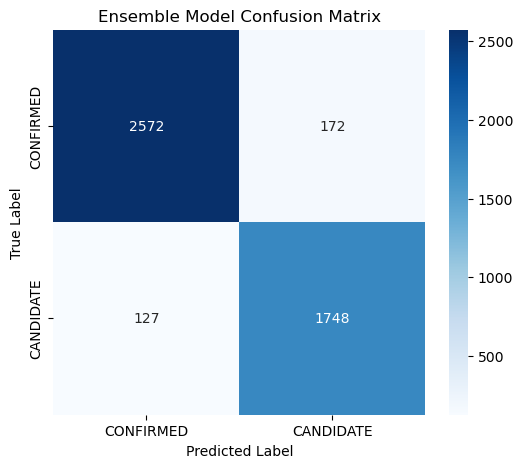

In [19]:
X_test_scaled = loaded_scaler.transform(X)

print("Test data has been scaled. Running ensemble predictions...")

# --- Step 2: Call your ensemble function on the entire test set ---
# This function will return the final predictions and probabilities for all test samples.
ensemble_preds, ensemble_probs = ensemble_predict(X_test_scaled, model, rf_model, bst, device)

# --- Step 3: Evaluate the Ensemble Model's Performance ---
# Calculate the accuracy
ensemble_accuracy = accuracy_score(y, ensemble_preds)
print(f"\nEnsemble Model Accuracy: {ensemble_accuracy:.4f}\n")

# Print a detailed classification report
# This shows precision, recall, and f1-score for each class.
print("Ensemble Classification Report:")
print(classification_report(y, ensemble_preds, target_names=['CONFIRMED', 'CANDIDATE']))

# --- Step 4: Visualize the results with a Confusion Matrix ---
# This helps you see exactly where the model is making correct and incorrect predictions.
print("Ensemble Confusion Matrix:")
cm_ensemble = confusion_matrix(y, ensemble_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues', xticklabels=['CONFIRMED', 'CANDIDATE'], yticklabels=['CONFIRMED', 'CANDIDATE'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Ensemble Model Confusion Matrix")
plt.show()
